# Data Science: Exploratory Data Analysis & Preparation
In this notebook, we'll explore the healthcare-dataset-stroke-data, analyze the distributions, and perform initial data cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid')

## 1. Load the Data

In [2]:
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Basic Information & Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
# Convert 'N/A' strings in 'bmi' to actual NaNs
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

# Check missing values
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## 3. Exploratory Data Analysis

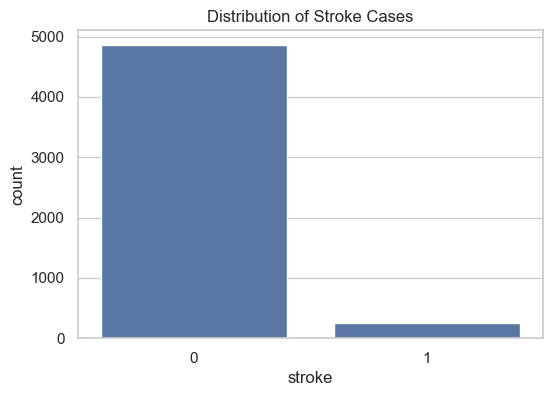

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='stroke')
plt.title('Distribution of Stroke Cases')
plt.show()

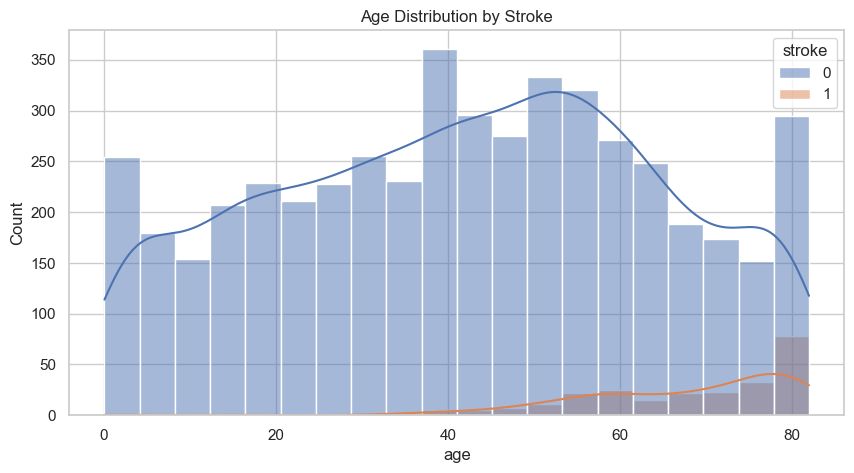

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='stroke', kde=True)
plt.title('Age Distribution by Stroke')
plt.show()

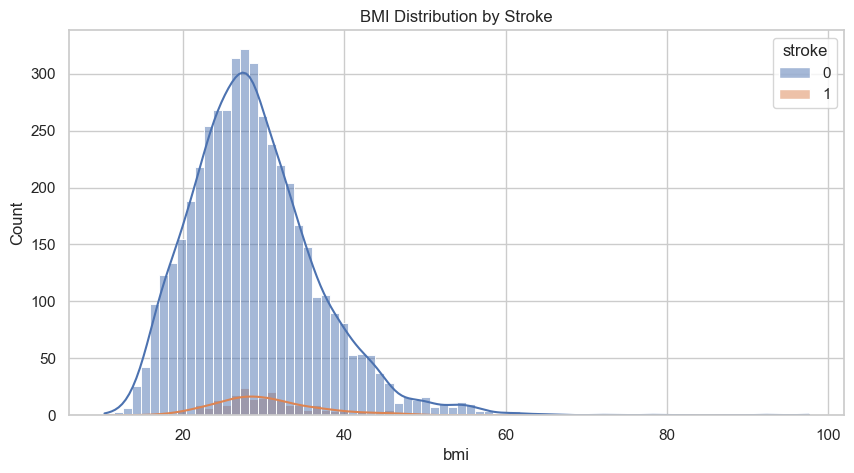

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='bmi', hue='stroke', kde=True)
plt.title('BMI Distribution by Stroke')
plt.show()

## 4. Data Cleaning

In [9]:
# Drop 'id' column as it's not a useful feature
df.drop('id', axis=1, inplace=True)

# Impute missing 'bmi' values with the median (or handle differently based on deeper analysis)
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)

# Remove 'Other' from gender to avoid small categories
df = df[df['gender'] != 'Other']

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_7544\2124700898.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(bmi_median, inplace=True)


## 5. Save Cleaned Data

In [10]:
cleaned_data_path = '../data/processed/stroke-data-cleaned.csv'
df.to_csv(cleaned_data_path, index=False)
print(f"Cleaned data saved to {cleaned_data_path}")

Cleaned data saved to ../data/processed/stroke-data-cleaned.csv
